In [10]:
import os
import glob
import wfdb
import numpy as np
import tensorflow as tf
import random
from scipy.signal import butter, sosfilt, medfilt, stft
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, classification_report, roc_auc_score,
    precision_recall_curve, f1_score
)
import matplotlib.pyplot as plt

from tensorflow.keras import layers, models, regularizers, optimizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Reproducibility
SEED = 42
np.random.seed(SEED)
random.seed(SEED)
tf.random.set_seed(SEED)

# Dataset folders - update these to your actual folders
af_folder = r"D:\8\mimic_perform_af_wfdb\mimic_perform_af_wfdb"
non_af_folder = r"D:\8\mimic_perform_non_af_wfdb\mimic_perform_non_af_wfdb"

# Signal / spectrogram settings
fs = 125
window_size_seconds = 15          # seconds per segment (captures rhythm)
window_size_samples = window_size_seconds * fs
overlap_ratio = 0.5               # 50% overlap
nperseg = 256                     # STFT window (samples)
noverlap = 128
eps = 1e-8

# Training
batch_size = 8


In [11]:
# Cell 2: Helper functions
def load_record(path_no_ext):
    return wfdb.rdrecord(path_no_ext)

def bandpass_filter(signal, lowcut, highcut, fs, order=4):
    sos = butter(order, [lowcut, highcut], btype="band", fs=fs, output="sos")
    return sosfilt(sos, signal)

def preprocess_signal(sig, sig_type='PPG'):
    sig = medfilt(sig, kernel_size=5)
    if sig_type == 'PPG':
        low, high = 0.5, 8.0
    else:
        low, high = 0.5, 40.0
    sig = bandpass_filter(sig, low, high, fs)
    std = np.std(sig)
    if std == 0:
        std = 1e-6
    return (sig - np.mean(sig)) / std

def segment_signal(signal):
    step = int(window_size_samples * (1 - overlap_ratio))
    segs = []
    for start in range(0, len(signal) - window_size_samples + 1, step):
        segs.append(signal[start:start + window_size_samples])
    return np.array(segs)

def compute_log_stft(sig):
    f, t, Zxx = stft(sig, fs=fs, nperseg=nperseg, noverlap=noverlap, boundary=None)
    return np.log1p(np.abs(Zxx) + eps).astype(np.float32)

def find_hea(folder):
    return glob.glob(os.path.join(folder, "**", "*.hea"), recursive=True)


In [12]:
# Cell 3: Discover files and subject-level stratified split
af_hea = find_hea(af_folder)
non_af_hea = find_hea(non_af_folder)

print("AF header files found:", len(af_hea))
print("Non-AF header files found:", len(non_af_hea))

af_records = [p[:-4] for p in af_hea]           # base paths without extension
non_af_records = [p[:-4] for p in non_af_hea]

all_paths = af_records + non_af_records
all_labels = [1] * len(af_records) + [0] * len(non_af_records)

# Basic checks
if len(all_paths) == 0:
    raise RuntimeError("No records found. Check af_folder/non_af_folder paths.")

# Subject-level split (no leakage)
X_trval, X_test, y_trval, y_test = train_test_split(
    all_paths, all_labels, test_size=0.2, stratify=all_labels, random_state=SEED
)
X_train, X_val, y_train, y_val = train_test_split(
    X_trval, y_trval, test_size=0.25, stratify=y_trval, random_state=SEED
)

print("Subjects -> Train:", len(X_train), "Val:", len(X_val), "Test:", len(X_test))
assert len(set(X_train) & set(X_val)) == 0
assert len(set(X_train) & set(X_test)) == 0
assert len(set(X_val) & set(X_test)) == 0


AF header files found: 19
Non-AF header files found: 16
Subjects -> Train: 21 Val: 7 Test: 7


In [13]:
X_train_paths, X_val_paths, X_test_paths = X_train, X_val, X_test
y_train_labels, y_val_labels, y_test_labels = y_train, y_val, y_test


In [14]:
import gc

# Cell 4: Convert records -> spectrogram segments
def convert_to_specs(paths, labels, verbose=False):
    specs, labs = [], []
    for path, lab in zip(paths, labels):
        try:
            rec = load_record(path)
        except Exception as e:
            if verbose: 
                print("Skipping", path, "Error:", e)
            continue

        if rec.p_signal is None or rec.p_signal.shape[1] < 2:
            if verbose:
                print("Skipping (missing ECG/PPG channels):", path)
            continue

        ppg = preprocess_signal(rec.p_signal[:,0], "PPG")
        ecg = preprocess_signal(rec.p_signal[:,1], "ECG")

        p_segs = segment_signal(ppg)
        e_segs = segment_signal(ecg)

        for ps, es in zip(p_segs, e_segs):
            p_spec = compute_log_stft(ps)
            e_spec = compute_log_stft(es)

            mf = min(p_spec.shape[0], e_spec.shape[0])
            mt = min(p_spec.shape[1], e_spec.shape[1])

            spec = np.stack([p_spec[:mf, :mt], e_spec[:mf, :mt]], axis=-1)

            if not np.isnan(spec).any():
                specs.append(spec)
                labs.append(lab)

    return np.array(specs, dtype=np.float32), np.array(labs, dtype=np.int32)


print("Converting TRAIN subjects...")
X_train, y_train = convert_to_specs(X_train_paths, y_train_labels, verbose=True)

print("Converting VAL subjects...")
X_val, y_val = convert_to_specs(X_val_paths, y_val_labels, verbose=True)

print("Converting TEST subjects...")
X_test, y_test = convert_to_specs(X_test_paths, y_test_labels, verbose=True)


print("Segment counts:")
print("  Train:", X_train.shape[0])
print("  Val:  ", X_val.shape[0])
print("  Test: ", X_test.shape[0])

gc.collect()


Converting TRAIN subjects...
Converting VAL subjects...
Converting TEST subjects...
Segment counts:
  Train: 2385
  Val:   954
  Test:  954


992

In [15]:
# Cell 5: tf.data pipelines, class weights, input shape
if X_train.size == 0:
    raise RuntimeError("No training segments created. Check segment length and folder contents.")

cw = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
class_weight = {int(k): float(v) for k,v in zip(np.unique(y_train), cw)}
print("Class weights:", class_weight)

train_ds = tf.data.Dataset.from_tensor_slices((X_train, y_train)).shuffle(len(X_train), seed=SEED).batch(batch_size).prefetch(tf.data.AUTOTUNE)
val_ds = tf.data.Dataset.from_tensor_slices((X_val, y_val)).batch(batch_size).prefetch(tf.data.AUTOTUNE)
test_ds = tf.data.Dataset.from_tensor_slices((X_test, y_test)).batch(batch_size).prefetch(tf.data.AUTOTUNE)

input_shape = X_train.shape[1:]
print("Input shape (freq, time, channels):", input_shape)

# Print class distribution
(unique, counts) = np.unique(y_train, return_counts=True)
print("Train distribution:", dict(zip(unique, counts)))
(unique, counts) = np.unique(y_val, return_counts=True)
print("Val distribution:", dict(zip(unique, counts)))
(unique, counts) = np.unique(y_test, return_counts=True)
print("Test distribution:", dict(zip(unique, counts)))


Class weights: {0: 1.0714285714285714, 1: 0.9375}
Input shape (freq, time, channels): (129, 14, 2)
Train distribution: {np.int32(0): np.int64(1113), np.int32(1): np.int64(1272)}
Val distribution: {np.int32(0): np.int64(318), np.int32(1): np.int64(636)}
Test distribution: {np.int32(0): np.int64(477), np.int32(1): np.int64(477)}


In [16]:
# Cell 6: Model builder (2D-CNN + Bi-LSTM)
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

def build_cnn_lstm(input_shape, lr=1e-4, l2_reg=1e-4, dropout=0.5, lstm_units=64):
    inp = layers.Input(shape=input_shape)
    x = layers.Conv2D(32, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2_reg))(inp)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D((2,2))(x); x = layers.Dropout(dropout)(x)

    x = layers.Conv2D(64, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D((2,2))(x); x = layers.Dropout(dropout)(x)

    x = layers.Conv2D(128, (3,3), padding='same', activation='relu',
                      kernel_regularizer=regularizers.l2(l2_reg))(x)
    x = layers.BatchNormalization()(x); x = layers.MaxPooling2D((2,2))(x); x = layers.Dropout(dropout)(x)

    x = layers.Permute((2,1,3))(x)
    time_steps = x.shape[1]
    feature_dim = x.shape[2] * x.shape[3]
    x = layers.Reshape((time_steps, feature_dim))(x)

    x = layers.Bidirectional(layers.LSTM(lstm_units))(x)
    x = layers.Dropout(dropout)(x)

    x = layers.Dense(64, activation='relu')(x)
    x = layers.Dropout(dropout)(x)
    out = layers.Dense(1, activation='sigmoid', dtype='float32')(x)

    model = models.Model(inputs=inp, outputs=out)
    model.compile(optimizer=Adam(lr),
                  loss=tf.keras.losses.BinaryCrossentropy(label_smoothing=0.05),
                  metrics=['accuracy', tf.keras.metrics.AUC(name='auc')])
    return model

model = build_cnn_lstm(input_shape, lr=1e-4, l2_reg=1e-4, dropout=0.5, lstm_units=64)
model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 129, 14, 2)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 129, 14, 32)    │           608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 129, 14, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 7, 32)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 7, 64)      │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64, 7, 64)      │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 3, 64)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 3, 128)     │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 32, 3, 128)     │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 1, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 1, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ permute (Permute)               │ (None, 1, 16, 128)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 1, 2048)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ (None, 128)            │     1,081,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,184,033 (4.52 MB)

 Trainable params: 1,183,585 (4.52 MB)

 Non-trainable params: 448 (1.75 KB)

In [17]:
# Cell 7: Train model
callbacks = [
    EarlyStopping(monitor='val_auc', mode='max', patience=6, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, verbose=1)
]

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=25,
    class_weight=class_weight,
    callbacks=callbacks,
    verbose=2
)

import tensorflow as tf
from tensorflow import keras

# ... (your model definition and training code here) ...

# Example: assuming you have a trained model object named 'model'
# You can save the entire model including architecture, weights, and optimizer state
save_path = 'AF_classification_model.keras'
model.save(save_path)

print(f"Model successfully saved to {save_path}")



Epoch 1/25
299/299 - 11s - 35ms/step - accuracy: 0.4943 - auc: 0.4984 - loss: 0.7334 - val_accuracy: 0.3333 - val_auc: 0.4930 - val_loss: 0.7300 - learning_rate: 1.0000e-04
Epoch 2/25
299/299 - 6s - 20ms/step - accuracy: 0.5140 - auc: 0.5236 - loss: 0.7169 - val_accuracy: 0.3344 - val_auc: 0.7505 - val_loss: 0.7281 - learning_rate: 1.0000e-04
Epoch 3/25
299/299 - 6s - 21ms/step - accuracy: 0.5539 - auc: 0.5655 - loss: 0.7040 - val_accuracy: 0.3344 - val_auc: 0.6837 - val_loss: 0.7467 - learning_rate: 1.0000e-04
Epoch 4/25
299/299 - 7s - 22ms/step - accuracy: 0.5589 - auc: 0.5918 - loss: 0.6942 - val_accuracy: 0.4948 - val_auc: 0.7504 - val_loss: 0.7086 - learning_rate: 1.0000e-04
Epoch 5/25
299/299 - 7s - 22ms/step - accuracy: 0.6084 - auc: 0.6582 - loss: 0.6710 - val_accuracy: 0.3543 - val_auc: 0.8312 - val_loss: 0.7390 - learning_rate: 1.0000e-04
Epoch 6/25
299/299 - 7s - 22ms/step - accuracy: 0.6872 - auc: 0.7613 - loss: 0.6110 - val_accuracy: 0.7893 - val_auc: 0.9409 - val_loss: 0.

30/30 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step
ROC AUC: 0.9953588333794814
              precision    recall  f1-score   support

      Non-AF       0.99      0.96      0.97       477
          AF       0.96      0.99      0.97       477

    accuracy                           0.97       954
   macro avg       0.97      0.97      0.97       954
weighted avg       0.97      0.97      0.97       954



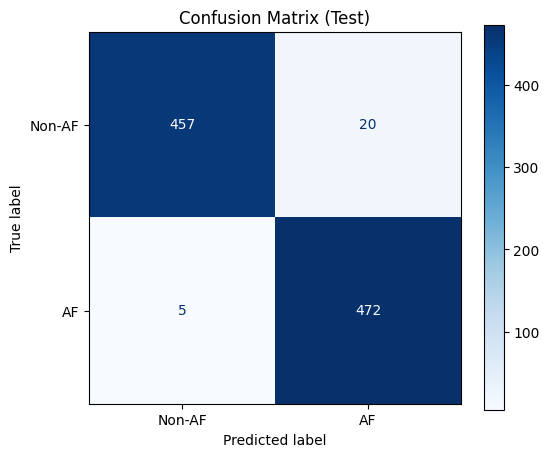

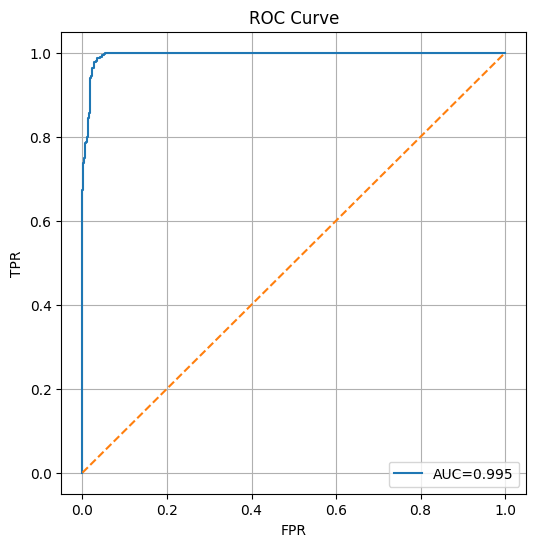

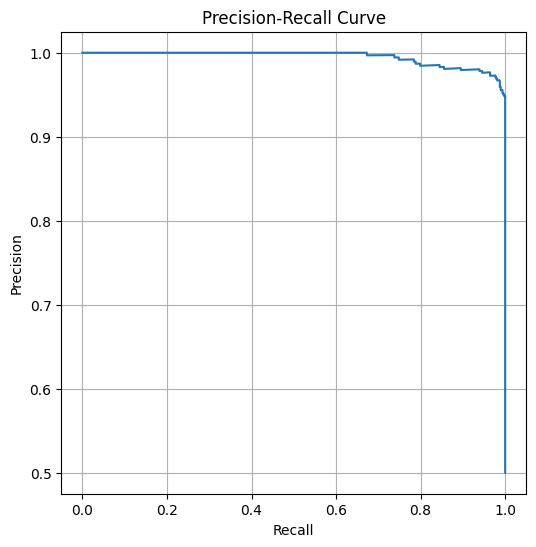

Best threshold by F1: 0.56 F1: 0.9761658031088083


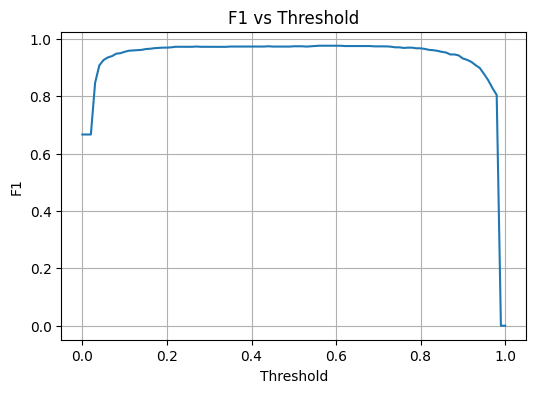

In [18]:
# Cell 8: Evaluation + metrics + plots
# Predictions
y_score = model.predict(X_test).ravel()
y_pred = (y_score >= 0.5).astype(int)

# Metrics
print("ROC AUC:", roc_auc_score(y_test, y_score))
print(classification_report(y_test, y_pred, target_names=['Non-AF','AF']))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=['Non-AF','AF']).plot(cmap='Blues', values_format='d', ax=plt.gca())
plt.title("Confusion Matrix (Test)")
plt.grid(False)
plt.show()

# ROC curve
fpr, tpr, _ = roc_curve(y_test, y_score)
roc_auc_val = auc(fpr, tpr)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC={roc_auc_val:.3f}"); plt.plot([0,1],[0,1],'--')
plt.xlabel("FPR"); plt.ylabel("TPR"); plt.title("ROC Curve"); plt.legend(); plt.grid(True); plt.show()

# PR curve
prec, rec, _ = precision_recall_curve(y_test, y_score)
plt.figure(figsize=(6,6))
plt.plot(rec, prec); plt.xlabel("Recall"); plt.ylabel("Precision"); plt.title("Precision-Recall Curve"); plt.grid(True); plt.show()

# Threshold tuning (F1 vs threshold)
thresholds = np.linspace(0,1,101)
f1s = [f1_score(y_test, (y_score >= t).astype(int)) for t in thresholds]
best_idx = int(np.nanargmax(f1s))
print("Best threshold by F1:", thresholds[best_idx], "F1:", f1s[best_idx])
plt.figure(figsize=(6,4)); plt.plot(thresholds, f1s); plt.xlabel("Threshold"); plt.ylabel("F1"); plt.title("F1 vs Threshold"); plt.grid(True); plt.show()


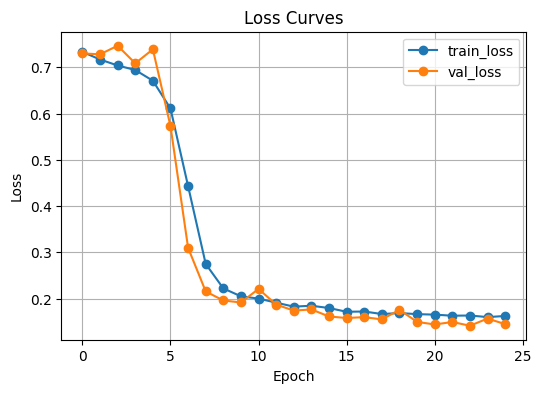

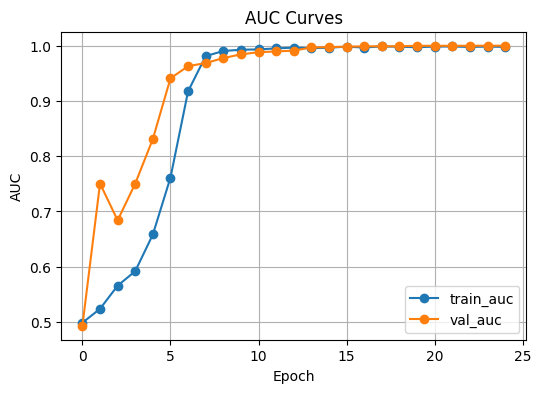

In [19]:
# Cell 9: Training curves
plt.figure(figsize=(6,4))
plt.plot(history.history['loss'], label='train_loss', marker='o')
plt.plot(history.history['val_loss'], label='val_loss', marker='o')
plt.xlabel("Epoch"); plt.ylabel("Loss"); plt.title("Loss Curves"); plt.legend(); plt.grid(True); plt.show()

if 'auc' in history.history:
    plt.figure(figsize=(6,4))
    plt.plot(history.history['auc'], label='train_auc', marker='o')
    plt.plot(history.history['val_auc'], label='val_auc', marker='o')
    plt.xlabel("Epoch"); plt.ylabel("AUC"); plt.title("AUC Curves"); plt.legend(); plt.grid(True); plt.show()


AF example: D:\8\mimic_perform_af_wfdb\mimic_perform_af_wfdb\mimic_perform_af_001


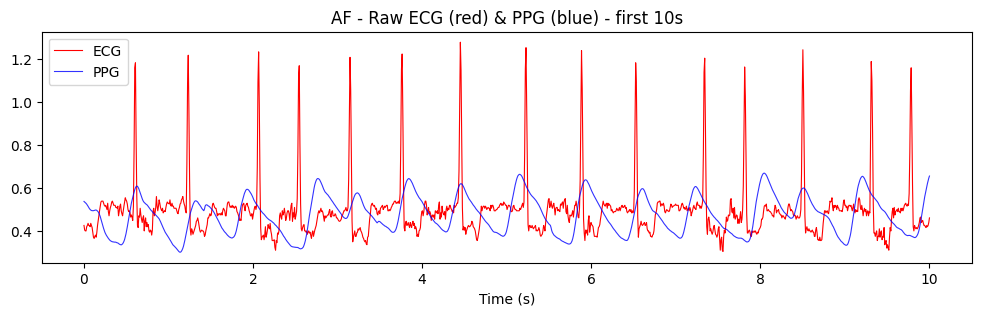

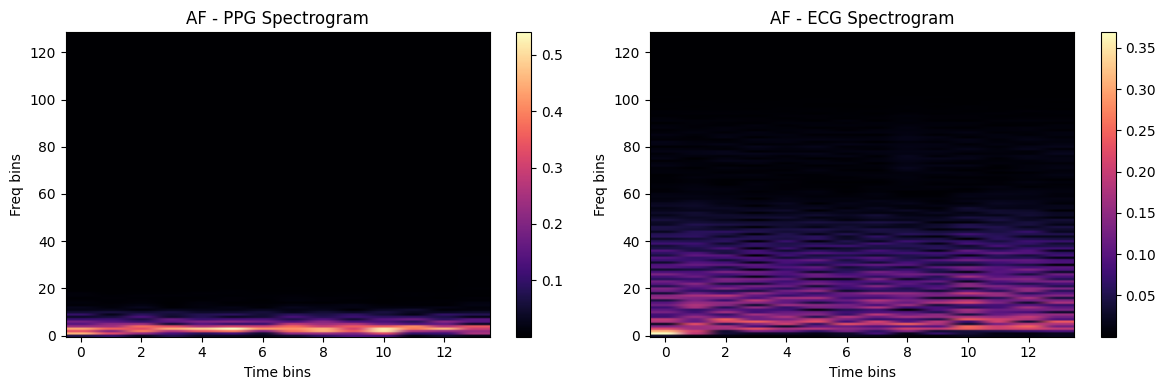

Non-AF example: D:\8\mimic_perform_non_af_wfdb\mimic_perform_non_af_wfdb\mimic_perform_non_af_001


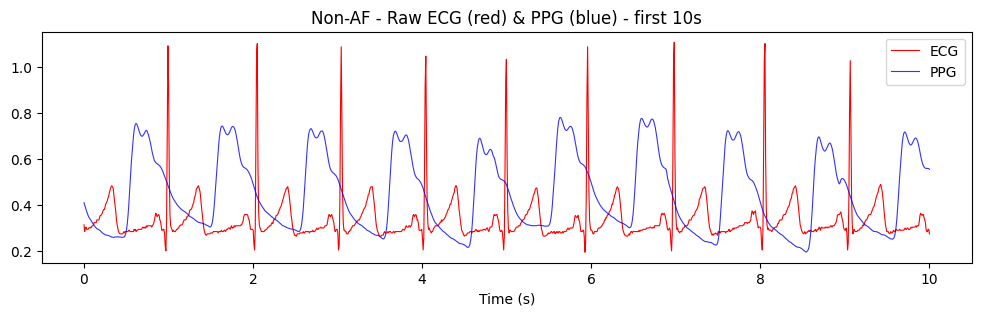

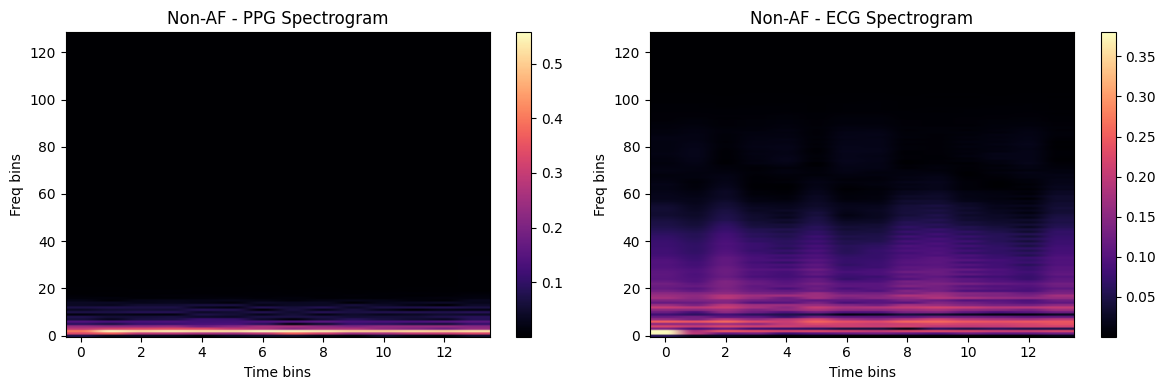

In [20]:
# Cell 10: Raw signal and spectrogram visualization for first AF & Non-AF subjects
def plot_raw_signals(record_path, prefix, seconds=10):
    rec = load_record(record_path)
    if rec.p_signal is None or rec.p_signal.shape[1] < 2:
        print("Missing channels:", record_path); return
    ppg_raw = rec.p_signal[:,0]; ecg_raw = rec.p_signal[:,1]
    N = min(len(ppg_raw), fs * seconds)
    t = np.linspace(0, N/fs, N)
    plt.figure(figsize=(12,3))
    plt.plot(t, ecg_raw[:N], label='ECG', color='red', linewidth=0.8)
    plt.plot(t, ppg_raw[:N], label='PPG', color='blue', linewidth=0.8, alpha=0.8)
    plt.title(f"{prefix} - Raw ECG (red) & PPG (blue) - first {seconds}s")
    plt.xlabel("Time (s)"); plt.legend(); plt.show()

def plot_specs_for_record(record_path, prefix):
    rec = load_record(record_path)
    ppg = preprocess_signal(rec.p_signal[:,0], 'PPG')
    ecg = preprocess_signal(rec.p_signal[:,1], 'ECG')
    p_segs = segment_signal(ppg); e_segs = segment_signal(ecg)
    if len(p_segs)==0:
        print("No segments for", record_path); return
    p_spec = compute_log_stft(p_segs[0]); e_spec = compute_log_stft(e_segs[0])
    mf = min(p_spec.shape[0], e_spec.shape[0]); mt = min(p_spec.shape[1], e_spec.shape[1])
    p_spec = p_spec[:mf,:mt]; e_spec = e_spec[:mf,:mt]
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1); plt.imshow(p_spec, aspect='auto', origin='lower', cmap='magma'); plt.title(f"{prefix} - PPG Spectrogram")
    plt.xlabel("Time bins"); plt.ylabel("Freq bins"); plt.colorbar()
    plt.subplot(1,2,2); plt.imshow(e_spec, aspect='auto', origin='lower', cmap='magma'); plt.title(f"{prefix} - ECG Spectrogram")
    plt.xlabel("Time bins"); plt.ylabel("Freq bins"); plt.colorbar()
    plt.tight_layout(); plt.show()

# pick first available AF and Non-AF
if len(af_records) > 0:
    print("AF example:", af_records[0])
    plot_raw_signals(af_records[0], "AF", seconds=10)
    plot_specs_for_record(af_records[0], "AF")

if len(non_af_records) > 0:
    print("Non-AF example:", non_af_records[0])
    plot_raw_signals(non_af_records[0], "Non-AF", seconds=10)
    plot_specs_for_record(non_af_records[0], "Non-AF")
